<a href="https://colab.research.google.com/github/Sarah4045/NLP-Projects/blob/main/Stroke_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_excel('/content/1- Dataset A&amp;amp;B.xlsx')

df

,MRN- Organization,Financial Number,Age- Years (Visit),Sex,Marital Status,Smoking Status,Diagnosis Description,Admit Date & Time,Diastolic Blood Pressure Result,Diastolic Blood Pressure Date/Time,Systolic Blood Pressure Result,Systolic Blood Pressure Date/Time,BMI Result,BMI Date&Time,Related Diagnosis,Unnamed: 15,Diabetes
0,1001,10710,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaT,DVT - Deep vein thrombosis,NaN,NaN
1,1001,10711,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaT,Embolism and thrombosis of unspecified vein,NaN,NaN
2,1001,10712,64.0,Male,Married,NaN,Stroke,2020-09-13 14:15:00,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaN,NaN
3,1001,10713,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaT,Embolism and thrombosis of vena cava,NaN,NaN
4,100,10714,64.0,Female,Married,NaN,Stroke,2020-08-26 08:51:00,NaN,NaT,NaN,NaT,NaN,NaT,Diabetes mellitus,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60480,999,10708,60.0,Male,Married,NaN,Stroke,2019-09-15 08:17:00,NaN,NaT,NaN,NaT,NaN,NaT,DM - Diabetes mellitus,NaN,NaN
60481,999,10708,60.0,Male,Married,NaN,Stroke,2019-09-15 08:17:00,NaN,NaT,NaN,NaT,NaN,NaT,Hand pain,NaN,NaN
60482,999,10708,60.0,Male,Married,NaN,Stroke,2019-09-15 08:17:00,NaN,NaT,NaN,NaT,NaN,NaT,Hypertension,NaN,NaN
60483,999,10708,60.0,Male,Married,NaN,Stroke,2019-09-15 08:17:00,NaN,NaT,NaN,NaT,NaN,NaT,Numbness,NaN,NaN


In [ ]:
df.isnull().sum()

,0
MRN- Organization,0
Financial Number,0
Age- Years (Visit),40655
Sex,40655
Marital Status,40655
Smoking Status,57024
Diagnosis Description,40655
Admit Date & Time,40655
Diastolic Blood Pressure Result,55862
Diastolic Blood Pressure Date/Time,55862


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60485 entries, 0 to 60484
Data columns (total 17 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   MRN- Organization                   60485 non-null  int64         
 1   Financial Number                    60485 non-null  int64         
 2   Age- Years (Visit)                  19830 non-null  float64       
 3   Sex                                 19830 non-null  object        
 4   Marital Status                      19830 non-null  object        
 5   Smoking Status                      3461 non-null   object        
 6   Diagnosis Description               19830 non-null  object        
 7   Admit Date & Time                   19830 non-null  datetime64[ns]
 8   Diastolic Blood Pressure Result     4623 non-null   float64       
 9   Diastolic Blood Pressure Date/Time  4623 non-null   datetime64[ns]
 10  Systolic Blood Pressur

In [ ]:
import pandas as pd

def diabetes_to_binary(value):
    if pd.isna(value):
        return 0
    if 'family history' in value.lower():
        return 0
    if 'diabetes' in value.lower():
        return 1
    return 0

df['Diabetes'] = df['Diabetes'].apply(diabetes_to_binary)


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report


df = df.drop(columns=df.select_dtypes(include='datetime64').columns)


for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == "object":
            df[col] = df[col].fillna("Unknown")
        else:
            df[col] = df[col].fillna(df[col].median())

le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])




In [ ]:
df.isnull().sum()

,0
MRN- Organization,0
Financial Number,0
Age- Years (Visit),40655
Sex,40655
Marital Status,40655
Smoking Status,57024
Diagnosis Description,40655
Admit Date & Time,40655
Diastolic Blood Pressure Result,55862
Diastolic Blood Pressure Date/Time,55862


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
X = df.drop(columns=["Diabetes"])
y = df["Diabetes"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Accuracy: 0.9226826848892318
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     16743
           1       0.50      0.00      0.00      1403

    accuracy                           0.92     18146
   macro avg       0.71      0.50      0.48     18146
weighted avg       0.89      0.92      0.89     18146

Confusion Matrix:
 [[16742     1]
 [ 1402     1]]


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report


model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:10:30] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.9604320511407473
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     16743
           1       0.85      0.59      0.70      1403

    accuracy                           0.96     18146
   macro avg       0.91      0.79      0.84     18146
weighted avg       0.96      0.96      0.96     18146

Confusion Matrix:
 [[16603   140]
 [  578   825]]


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report


model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Accuracy: 0.9772952716852199
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     16743
           1       0.83      0.88      0.86      1403

    accuracy                           0.98     18146
   macro avg       0.91      0.93      0.92     18146
weighted avg       0.98      0.98      0.98     18146

Confusion Matrix:
 [[16495   248]
 [  164  1239]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


Accuracy: 0.9760828832800618
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     16743
           1       0.89      0.79      0.84      1403

    accuracy                           0.98     18146
   macro avg       0.93      0.89      0.91     18146
weighted avg       0.98      0.98      0.98     18146

Confusion Matrix:
 [[16602   141]
 [  293  1110]]


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix


model = SVC(random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


Accuracy: 0.9226826848892318
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     16743
           1       0.00      0.00      0.00      1403

    accuracy                           0.92     18146
   macro avg       0.46      0.50      0.48     18146
weighted avg       0.85      0.92      0.89     18146

Confusion Matrix:
 [[16743     0]
 [ 1403     0]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

In [ ]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report


model = lgb.LGBMClassifier(random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

[LightGBM] [Info] Number of positive: 3256, number of negative: 39083
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004128 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1348
[LightGBM] [Info] Number of data points in the train set: 42339, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.076903 -> initscore=-2.485188
[LightGBM] [Info] Start training from score -2.485188
Accuracy: 0.9547007604981814
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     16743
           1       0.87      0.49      0.62      1403

    accuracy                           0.95     18146
   macro avg       0.91      0.74      0.80     18146
weighted avg       0.95      0.95      0.95     18146

Confusion Matrix:
 [[16640   103]
 [  719   684]]


In [ ]:
pip install shap

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:11:46] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.9609820616681822
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11158
           1       0.87      0.59      0.70       939

    accuracy                           0.96     12097
   macro avg       0.92      0.79      0.84     12097
weighted avg       0.96      0.96      0.96     12097



 99%|===================| 11919/12097 [00:46<00:00]       

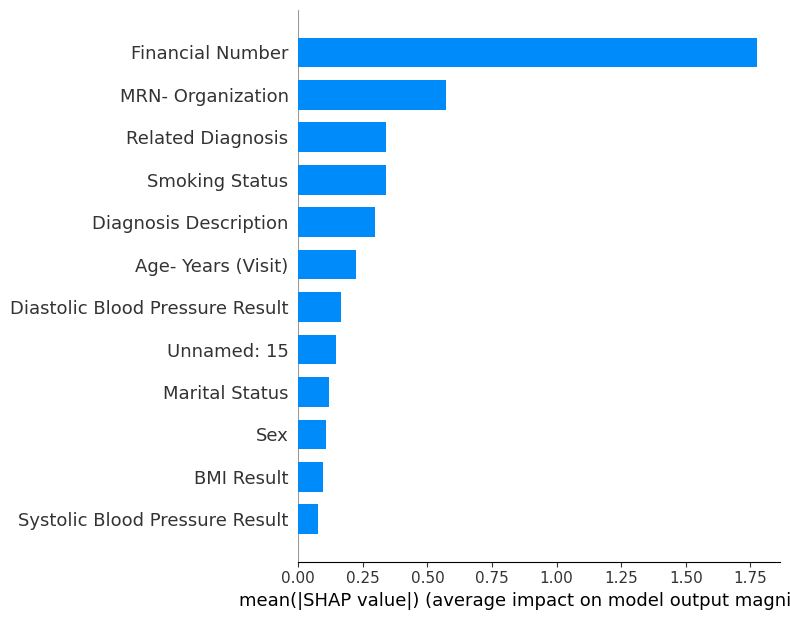

In [ ]:
import shap
import xgboost as xgb
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


X = df.drop(columns=["Diabetes"])
y = df["Diabetes"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)


shap.summary_plot(shap_values, X_test, plot_type="bar")
